In [ ]:
!pip install -q langchain_openai langchain langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.1 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
openai_api_key = userdata.get('openai_api_key')

In [ ]:
from langchain_openai import ChatOpenAI

chat_gpt_4_vision = ChatOpenAI(api_key=openai_api_key, model="gpt-4o-mini")


# Encoding and Decoding: An Overview

## What is Encoding and Decoding?

**Encoding** is the process of converting data from its original format into a specific code for efficient transmission or storage. **Decoding** is the reverse process—converting that encoded data back into its original format, essentially "reading" the encoded information.

### In Simple Terms:
- **Encoding** is like writing a message in code.
- **Decoding** is like deciphering that code to understand the original message.

### Applications:
Encoding and decoding are essential in various fields, such as:
- **Computer Science**: To store and transmit data effectively.
- **Communication**: To ensure secure and efficient data transfer.
- **Data Transmission**: For efficient sending of information over networks.
- **Language Processing**: Converting written language into a format computers can understand.

### Examples:
- **Text Encoding**: Converting plain text into formats like **ASCII** or **Unicode** for digital storage.
- **Video Encoding**: Compressing video footage into smaller file sizes for easier streaming or storage.
- **Encryption**: Encoding data with a secret key to protect its privacy.

---

# What is Base64 and How Does It Work?

**Base64** is a specific encoding scheme used to convert binary data into a text format using a set of 64 printable ASCII characters. It’s commonly used in email transmission, URL encoding, and embedding complex data (like images) into text-based formats (like HTML or JSON).

### How Base64 Works:
1. **Data Conversion**: Base64 takes binary data (0s and 1s) and divides it into groups of 6 bits. Since 6 bits represent 64 unique values, each 6-bit chunk is then mapped to one of the 64 characters in the Base64 alphabet.
   
2. **Base64 Alphabet**: The Base64 alphabet includes uppercase letters (A-Z), lowercase letters (a-z), digits (0-9), and two special characters (`+` and `/` in the standard Base64 alphabet).

3. **Padding**: If the data being encoded doesn’t align perfectly into 6-bit chunks, Base64 adds `=` characters as padding at the end to complete the encoding process.

### Why Use Base64?
- **Data Representation**: It ensures that binary data can be safely transmitted over text-based protocols (like email or HTTP), which often have restrictions on what characters can be sent.
- **Portability**: Base64 encoded data can easily be included in URLs, cookies, or embedded directly into source code (like for embedding images in HTML).


In [ ]:
import os
import base64

# Function to encode images
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')


In [ ]:
path_to_image = '/content/aroos_holandi0.jpg'
result = encode_image(path_to_image)

In [ ]:
result

In [ ]:
image_data = base64.b64decode(result)
with open("decoded_image.jpg", "wb") as image_file:
    image_file.write(image_data)

In [ ]:
from langchain.schema.messages import HumanMessage, AIMessage,SystemMessage
from langchain.prompts import ChatMessagePromptTemplate
from langchain.output_parsers import StructuredOutputParser, ResponseSchema
from langchain.prompts import PromptTemplate, ChatPromptTemplate, HumanMessagePromptTemplate

In [ ]:
from langchain.prompts import (
    ChatPromptTemplate,
    MessagesPlaceholder,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
)
from langchain.chat_models import ChatOpenAI
from langchain.prompts import PromptTemplate


In [ ]:
from langchain_openai import ChatOpenAI
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('openai_api_key')
llm = ChatOpenAI(model="gpt-4o-mini")

In [ ]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Describe the image provided"),
        (
            "user",
            [
                {
                    "type": "image_url",
                    "image_url": {"url": "data:image/jpeg;base64,{image_data}"},
                }
            ],
        ),
    ]
)

In [ ]:
path = '/content/aroos_holandi0.jpg'
path = "/content/dog_01.jpg"
path = "/content/watermelon.jpg"  # Replace with desired JPEG file path

image_data = encode_image(path)

In [ ]:
chain = prompt | llm

response = chain.invoke({"image_data": image_data})
print(response.content)

The image shows a small, oval-shaped green watermelon growing on a vine. The watermelon is still immature and has light green stripes. Surrounding the fruit are broad, jagged leaves typical of watermelon plants, and the ground appears to be dirt with some wooden planks visible in the background, likely used for support or to control growth. The scene indicates a garden or cultivation area.


In [ ]:

from PIL import Image

def convert_jpg_to_jpeg(jpg_path, jpeg_path):
    try:
        img = Image.open(jpg_path)
        img.save(jpeg_path, "JPEG")
        print(f"Image converted and saved as {jpeg_path}")
    except FileNotFoundError:
        print(f"Error: Input file not found at {jpg_path}")
    except Exception as e:
        print(f"An error occurred: {e}")


# Example usage
jpg_file_path = "/content/watermelon.jpg"  # Replace with your JPG file path
jpeg_file_path = "/content/watermelon.jpeg"  # Replace with desired JPEG file path

convert_jpg_to_jpeg(jpg_file_path, jpeg_file_path)


Image converted and saved as /content/watermelon.jpeg


In [ ]:
from  langchain_core.output_parsers import StrOutputParser

In [ ]:
messages = [
SystemMessage(content="You are a bot that is good at detecting plant issues.always answer in persian"),
        ('user', [
            {"type": "text", "text":"""please detect plant type and any pest and diseases on plant."""},
              {
                "type": "image_url",
                "image_url": {
                    "url": "data:image/jpeg;base64,{encoded_image}"
                },
            },
        ])
        ]
prompt = ChatPromptTemplate(messages=messages)
chain = prompt | llm | StrOutputParser()

image_data = encode_image('/content/watermelon.jpg')


response = chain.invoke({'encoded_image':image_data})
response

'این گیاه احتمالاً خربزه یا هندوانه است. \n\nبررسی مشکلات گیاهی:\n1. **آفت\u200cها**: ممکن است آفات مختلفی مانند مگس\u200cهای میوه یا شته\u200cها وجود داشته باشد. \n2. **بیماری\u200cها**: علائمی مانند لکه\u200cهای زرد یا قهوه\u200cای روی برگ\u200cها می\u200cتواند نشان\u200cدهنده بیماری\u200cهای قارچی باشد.\n\nبرای تشخیص دقیق\u200cتر و درمان، بهتر است از متخصص گیاه\u200cپزشکی یا یک باغبان مشاوره بگیرید.'

In [ ]:
def plant_detector(llm, encoded_image):
  messages = [
  SystemMessage(content="You are a bot that is good at detecting plant issues.always answer in persian"),
          HumanMessage(content=[
              {"type": "text", "text":"""please detect plant type and any pest and diseases on plant."""},
                {
                  "type": "image_url",
                  "image_url": {
                      "url": f"data:image/png;base64,{encoded_image}"
                  },
              },
          ])
          ]
  prompt = ChatPromptTemplate( messages=messages)

  response = llm.invoke(prompt.messages)
  return  response.content

In [ ]:

plant_detector(llm, image_data)

'این گیاه به احتمال زیاد خربزه یا هندوانه است. \n\n### مشکلات و آفات احتمالی:\n1. **پوسیدگی ریشه**: اگر برگ\u200cها زرد می\u200cشوند، ممکن است به دلیل آبیاری بیش از حد یا خاک مرطوب باشد.\n2. **آفات**:\n   - **پسیل\u200cهای گیاهی**: می\u200cتوانند باعث زرد شدن و پژمردگی برگ\u200cها شوند.\n   - **کنه\u200cها**: به خصوص در شرایط گرم، می\u200cتوانند شیره گیاه را مکیده و آسیب دیده کنند.\n\n### بیماری\u200cها:\n- **بیماری\u200cهای قارچی**: مثل «پوسیدگی ساقه» که به علت رطوبت زیاد در خاک به وجود می\u200cآید.\n- **بیماری ویروسی**: که ممکن است باعث تغییر رنگ یا عوارض دیگر بر روی برگ\u200cها و میوه\u200cها شود.\n\nاگر نشانه\u200cهای خاص\u200cتری مشاهده کردید، می\u200cتوانیم بیشتر بررسی کنیم.'

In [ ]:
def pet_detector(llm, encoded_image):
  prompt = [
  SystemMessage(content="You are an excellent pet breed detector."),
          HumanMessage(content=[
              {"type": "text", "text": "please detect pet breed and type."},
              {
                  "type": "image_url",
                  "image_url": {
                      "url": f"data:image/png;base64,{encoded_image}"
                  },
              },
          ])
          ]
  response = llm.invoke(prompt)
  return  response.content

In [ ]:
encoded_image = encode_image('/content/dog_01.jpg')
pet_detector(llm, encoded_image)

'The pet in the image appears to be a dog, specifically an **American Cocker Spaniel**. They are known for their long ears, friendly demeanor, and beautiful coat.'

In [ ]:
encoded_image = encode_image('/content/ariss_02.jpg')
response = plant_detector(chat_gpt_4_vision, encoded_image)

In [ ]:
with open('output.txt', 'w', encoding='utf-8') as w:
  w.write(response)

In [ ]:
def pet_qa(llm, question, encoded_image):
  prompt = [
  SystemMessage(content="You are a helpful and experienced vet, please only provide general guidance.always answer in ENGLISH"),
  HumanMessage(content=[
              {"type": "text", "text": "please help me about pets"},
              {"type": "text", "text": f"please answer {question}"},
              {
                  "type": "image_url",
                  "image_url": {
                      "url": f"data:image/png;base64,{encoded_image}"
                  },
              },
          ])
          ]
  # print(prompt)
  response = llm.invoke(prompt).content
  return response

In [ ]:
def plant_qa(llm, encoded_image, question):
  prompt = [
  SystemMessage(content="You are a helpful and experienced farmer assistant, always answer in Persian"),
          HumanMessage(content=[
              {"type": "text", "text": "please detect plant type and any pest and diseases on plant."},
              {"type": "text", "text": f"please answer {question},Feel free to provide information on each topic only if the question is asked ,topics : Fertilizer, Watering Schedule, Pesticides, Disease Management"},
              {
                  "type": "image_url",
                  "image_url": {
                      "url": f"data:image/png;base64,{encoded_image}"
                  },
              },
          ])
          ]
  # print(prompt)
  response = llm.invoke(prompt)
  return  response.content

In [ ]:
question = """سلام یه تعداد گردو دارم که اواسط خرداد برگشون شروع میکنه خشک شدن هم وسط برگ ها هم اطراف میشه ببینید مشکلشون چیه"""
encoded_image = encode_image('/content/ariss_01.jpg')
plant_qa(chat_gpt_4_vision, encoded_image, question)

'سلام! به نظر می\u200cرسه که برگ\u200cهای گردوی شما به بیماری بلایت (آتشک) یا کمبود مواد مغذی دچار شده\u200cاند. این بیماری می\u200cتواند باعث خشک شدن نوک و حاشیه برگ\u200cها شود.\n\n### اقدامات پیشنهادی:\n\n#### مدیریت بیماری:\n- برگ\u200cهای آلوده را بردارید و از بین ببرید تا از گسترش بیماری جلوگیری شود.\n- استفاده از قارچ\u200cکش\u200cهای مناسب می\u200cتواند مفید باشد.\n\n#### کوددهی:\n- مطمئن شوید که درختان شما به اندازه کافی از عناصر غذایی مثل پتاسیم و نیتروژن بهره\u200cمند هستند. تست خاک می\u200cتواند به تعیین کمبودها کمک کند.\n\n#### برنامه آبیاری:\n- آبیاری منظم و عمیق انجام دهید، اما از تجمع آب در اطراف ریشه\u200cها جلوگیری کنید.\n\n#### سمپاشی:\n- برای پیشگیری و کنترل آفات و بیماری\u200cها، از سموم مناسب استفاده کنید.\n\nدر صورت ادامه مشکل، مشاوره با یک کارشناس کشاورزی می\u200cتواند مفید باشد.'

In [ ]:
content = []

for path in ['/content/ariss000.jpg', '/content/ariss001.jpg', '/content/ariss002.jpg']:
  image_data = encode_image(path)
  content.append({'type': 'image_url',
                  'image_url':
                   {'url': f'data:image/png;base64,{image_data}', 'detail': 'high'}
                  })



[{'type': 'image_url',
  'image_url': {'url': '',
   'detail': 'high'}},
 {'type': 'image_url',
  'image_url': {'url': '',
   'detail': 'high'}},
 {'type': 'image_url',
  'image_url': {'url': '',
   'detail': 'high'}}]
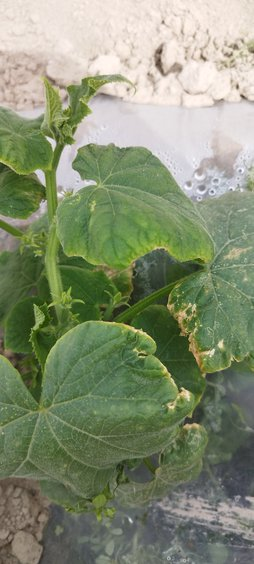
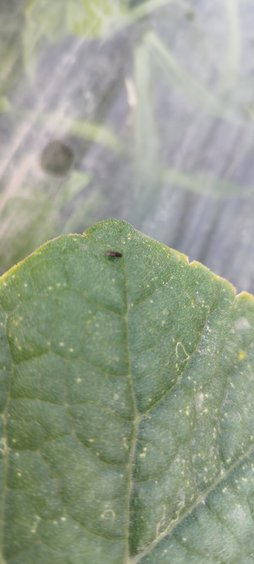
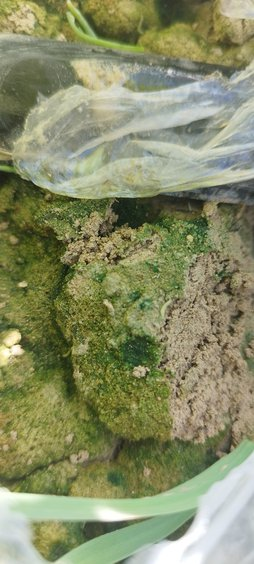

In [ ]:
content

In [ ]:

query = """سم پاشی
با سلام،آیا سم امامکتین بنزوات برای سم پاشی خیار سبز ضرر ندارد؟"""
messages = [("system", "you are a helpful assistant, please answer based  on provided images"),
            ('user', query),
        (
            "user", content
            ,
        ),

]
chain = llm | StrOutputParser()
response = chain.invoke(messages)
print(response)

سم پاشی با سم امامکتین بنزوات می‌تواند بر روی خیار سبز موثر باشد، اما بستگی به دوز و شرایط خاص محیط نیز دارد. در صورت استفاده نادرست، ممکن است به گیاه آسیب برساند.

بهتر است قبل از سم پاشی، دستورالعمل‌های کارخانه را به دقت مطالعه کنید و همچنین به اثرات جانبی آن توجه داشته باشید. در صورتی که گیاهان شما دارای علائم عفونت یا آفت هستند، شناسایی و درمان آنها به طور دقیق ضروری است. از مشاوره کارشناسان گیاه‌پزشکی محلی نیز بهره‌مند شوید تا بهترین نتیجه را بدست آورید.


In [ ]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "you are a helpful assistant"),
        (
            "user",
            [
                {
                    "type": "image_url",
                    "image_url": {"url": "data:image/jpeg;base64,{image_data}"},
                }
            ],
        ),
        MessagesPlaceholder(variable_name="chat_history"),

    ]
)

In [ ]:
chain = prompt | llm | StrOutputParser()

chat_history = [HumanMessage(content="""سم های زمستانه برای درختان
سلام چه سم هایی برای درختان قبل باز شدن بزنیم""")]
encoded_image = encode_image('/content/watermelon.jpeg')
response = chain.invoke({'chat_history':chat_history, 'image_data': encoded_image})
print(response)

سلام! سم‌پاشی زمستانه درختان به کنترل آفات و بیماری‌ها کمک می‌کند. برخی از سم‌های مناسب برای این کار عبارتند از:

1. **سم چسبنده (Oil Spray)**: این سم به از بین بردن تخم‌گذارها و آفات زمستانه کمک می‌کند.

2. **پودر گوگرد**: برای مبارزه با بیماری‌های قارچی و آفت‌ها مؤثر است.

3. **کاربندازیم**: سم قارچ‌کش برای کنترل بیماری‌های قارچی.

4. **نئوپرامین**: یک حشره‌کش مؤثر برای کنترل آفات.

5. **سم‌های معدنی**: مانند سم‌های ضد قارچ که می‌توانند در پیشگیری از ظهور بیماری‌ها کمک کنند.

قبل از استفاده از هر سم، توجه به راهنمایی‌های مربوط به دوز و زمان مصرف بسیار مهم است. همچنین بهتر است با کارشناس کشاورزی یا باغبانی مشورت کنید.


In [ ]:
chat_history.append(AIMessage(content=response))

In [ ]:
chat_history.append(HumanMessage(content="""با سلام و وقت بخیر
بستگی به نوع درختان می توانید از روغن ولک قبل از بیداری به صورت محلولپاشی استفاده کنید. درختان در مرحله تورم جوانه با سموم مسی مانند نوردوکس و بردفیکس سمپاشی شوند. محلولپاشی با کودهای آمینو اسید و جلبک دریایی و فروت ست در مرحله تورم جوانه و قبل از گلدهی انجام شوند. نوع درختان و سن آن ها را بفرمائید‌"""))